In [1]:
#imports and reading the file as well as the top 10 lines
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('goodreads_sf_books_clean.csv', index_col=0)
print(df.shape)

df.head(10
        )

(1246, 8)


,title,author,pub_year,avg_rate,num_rate,shelved,series_name,series_num
0,Dune,Frank Herbert,1965,4.25,1128771,17356,Dune,1.0
1,Ender's Game,Orson Scott Card,1985,4.30,1273765,16692,Ender's Saga,1.0
2,The Hitchhiker's Guide to the Galaxy,Douglas Adams,1979,4.23,1679109,15896,Hitchhiker's Guide to the Galaxy,1.0
3,The Martian,Andy Weir,2011,4.41,990146,14130,NaN,NaN
4,Ready Player One,Ernest Cline,2011,4.24,1044522,12187,Ready Player One,1.0
5,Fahrenheit 451,Ray Bradbury,1953,3.98,2098080,11942,NaN,NaN
6,1984,George Orwell,1949,4.19,3968565,11599,NaN,NaN
7,The Hunger Games,Suzanne Collins,2008,4.32,7605395,11439,The Hunger Games,1.0
8,Brave New World,Aldous Huxley,1932,3.99,1679609,10532,NaN,NaN
9,Foundation,Isaac Asimov,1951,4.17,487319,10185,Foundation,1.0


In [2]:
#finding nulls and filling them
df.isnull().sum()
df.fillna({"series_name": "No Series", "series_num": 0}, inplace=True)



,title,author,pub_year,avg_rate,num_rate,shelved,series_name,series_num
0,Dune,Frank Herbert,1965,4.25,1128771,17356,Dune,1.0
1,Ender's Game,Orson Scott Card,1985,4.30,1273765,16692,Ender's Saga,1.0
2,The Hitchhiker's Guide to the Galaxy,Douglas Adams,1979,4.23,1679109,15896,Hitchhiker's Guide to the Galaxy,1.0
3,The Martian,Andy Weir,2011,4.41,990146,14130,No Series,0.0
4,Ready Player One,Ernest Cline,2011,4.24,1044522,12187,Ready Player One,1.0
...,...,...,...,...,...,...,...,...
1241,Embers of War,Gareth L. Powell,2018,3.91,5111,337,Embers of War,1.0
1242,Camouflage,Joe Haldeman,2004,3.65,6008,337,No Series,0.0
1243,The Time Machine/The Invisible Man,H.G. Wells,1968,4.10,55658,336,No Series,0.0
1244,The Young Elites,Marie Lu,2014,3.88,128095,336,The Young Elites,1.0


In [3]:
#checking null count
df.isnull().sum()

title          0
author         0
pub_year       0
avg_rate       0
num_rate       0
shelved        0
series_name    0
series_num     0
dtype: int64

In [ ]:
#checking data types
df.dtypes

title              str
author             str
pub_year         int64
avg_rate       float64
num_rate         int64
shelved          int64
series_name        str
series_num     float64
dtype: object

In [ ]:
#duplicate values check
df.duplicated(keep=False).sum()

np.int64(2)

In [ ]:
#listing duplicates
df.loc[df.duplicated(keep=False)].sort_values("title")

,title,author,pub_year,avg_rate,num_rate,shelved,series_name,series_num
196,The End of Eternity,Isaac Asimov,1955,4.24,51491,1787,No Series,0.0
197,The End of Eternity,Isaac Asimov,1955,4.24,51491,1787,No Series,0.0


In [ ]:
#author counting
df["author"].value_counts()

author
Robert A. Heinlein      32
Isaac Asimov            31
Anne McCaffrey          27
Orson Scott Card        22
Lois McMaster Bujold    21
                        ..
K.B. Wagers              1
Alex London              1
Félix J. Palma           1
Gareth L. Powell         1
Caragh M. O'Brien        1
Name: count, Length: 429, dtype: int64

In [ ]:
#data description
df.describe()

,pub_year,avg_rate,num_rate,shelved,series_num
count,1246.000000,1246.000000,1.246000e+03,1246.000000,1246.000000
mean,1996.407705,3.980361,1.258548e+05,1191.534510,1.460594
std,24.352843,0.223996,4.649627e+05,1636.261939,2.138429
min,1818.000000,3.210000,2.843000e+03,336.000000,0.000000
25%,1986.000000,3.840000,1.223875e+04,444.000000,0.000000
50%,2005.000000,3.980000,2.567500e+04,629.000000,1.000000
75%,2014.000000,4.140000,7.579500e+04,1146.250000,2.000000
max,2022.000000,4.570000,8.826466e+06,17356.000000,16.000000


<Axes: >

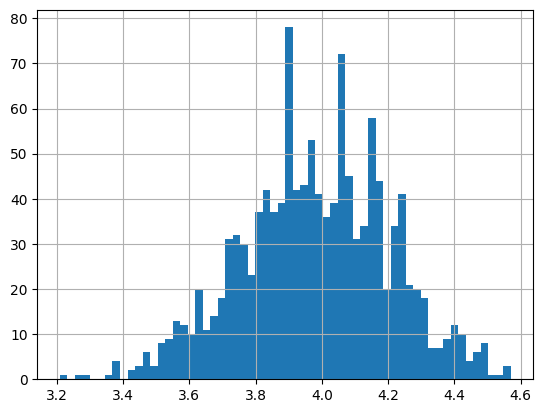

In [ ]:
#histograph of average rating
df["avg_rate"].hist(bins=60)

<Axes: xlabel='avg_rate'>

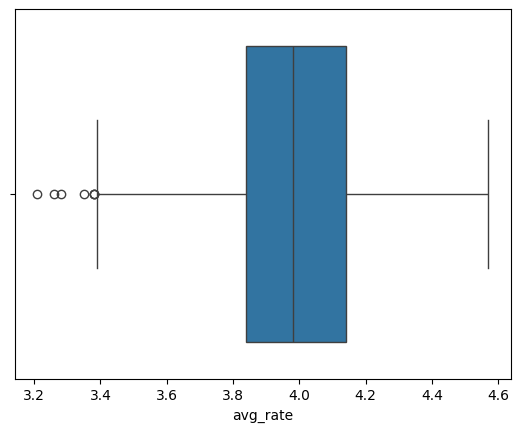

In [ ]:
#boxplot of average rating
sns.boxplot(x=df["avg_rate"])

In [ ]:
#making a table with  'pub_year', 'avg_rate', 'num_rate', 'shelved'
df.columns
df_corr = df[[ 'pub_year', 'avg_rate', 'num_rate', 'shelved']].corr()

df_corr
       

,pub_year,avg_rate,num_rate,shelved
pub_year,1.000000,0.071989,-0.078136,-0.164974
avg_rate,0.071989,1.000000,0.140720,0.200914
num_rate,-0.078136,0.140720,1.000000,0.438184
shelved,-0.164974,0.200914,0.438184,1.000000


<Axes: >

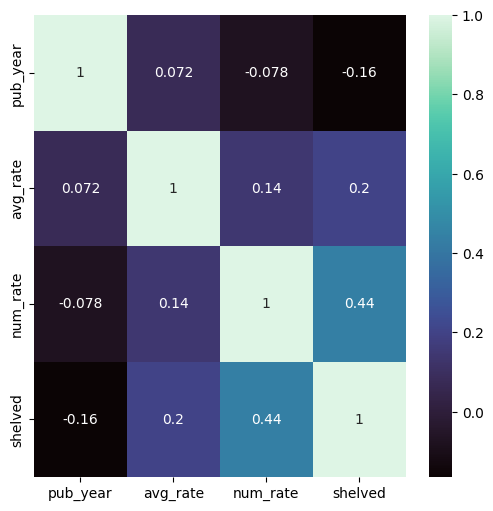

In [ ]:
#plotting that into a heatmap
fig, ax = plt.subplots(figsize=(6,6))
sns.heatmap(df_corr, annot=True, cmap="mako")

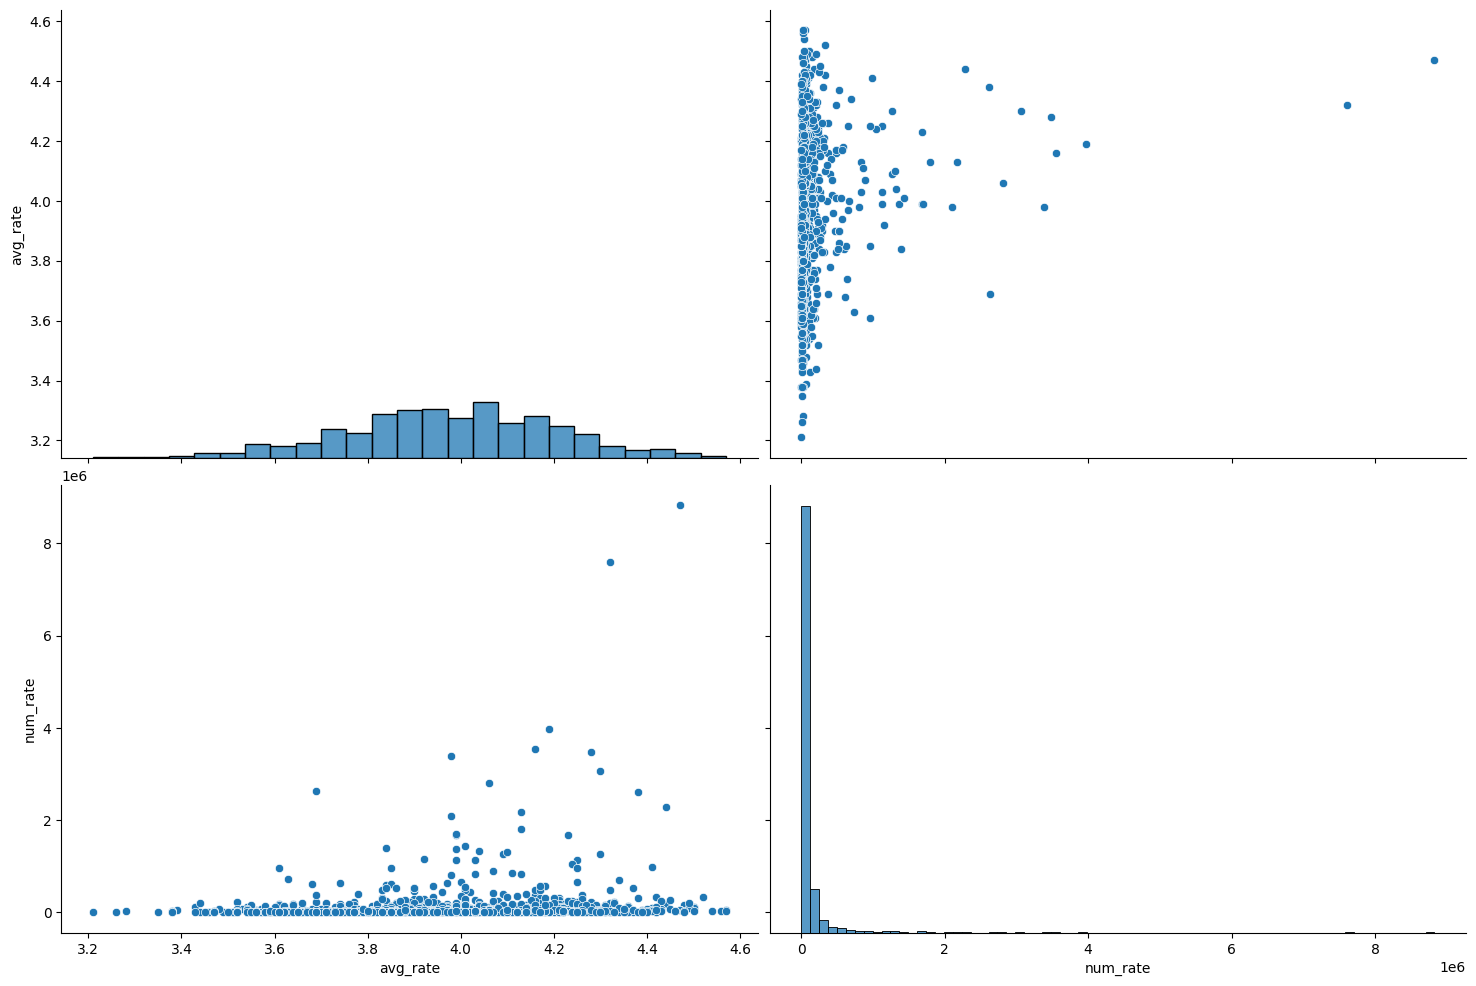

In [ ]:
# a pair plot to look for corrolations
sns.pairplot(df[["avg_rate", "num_rate"]], height=5, aspect=1.5)

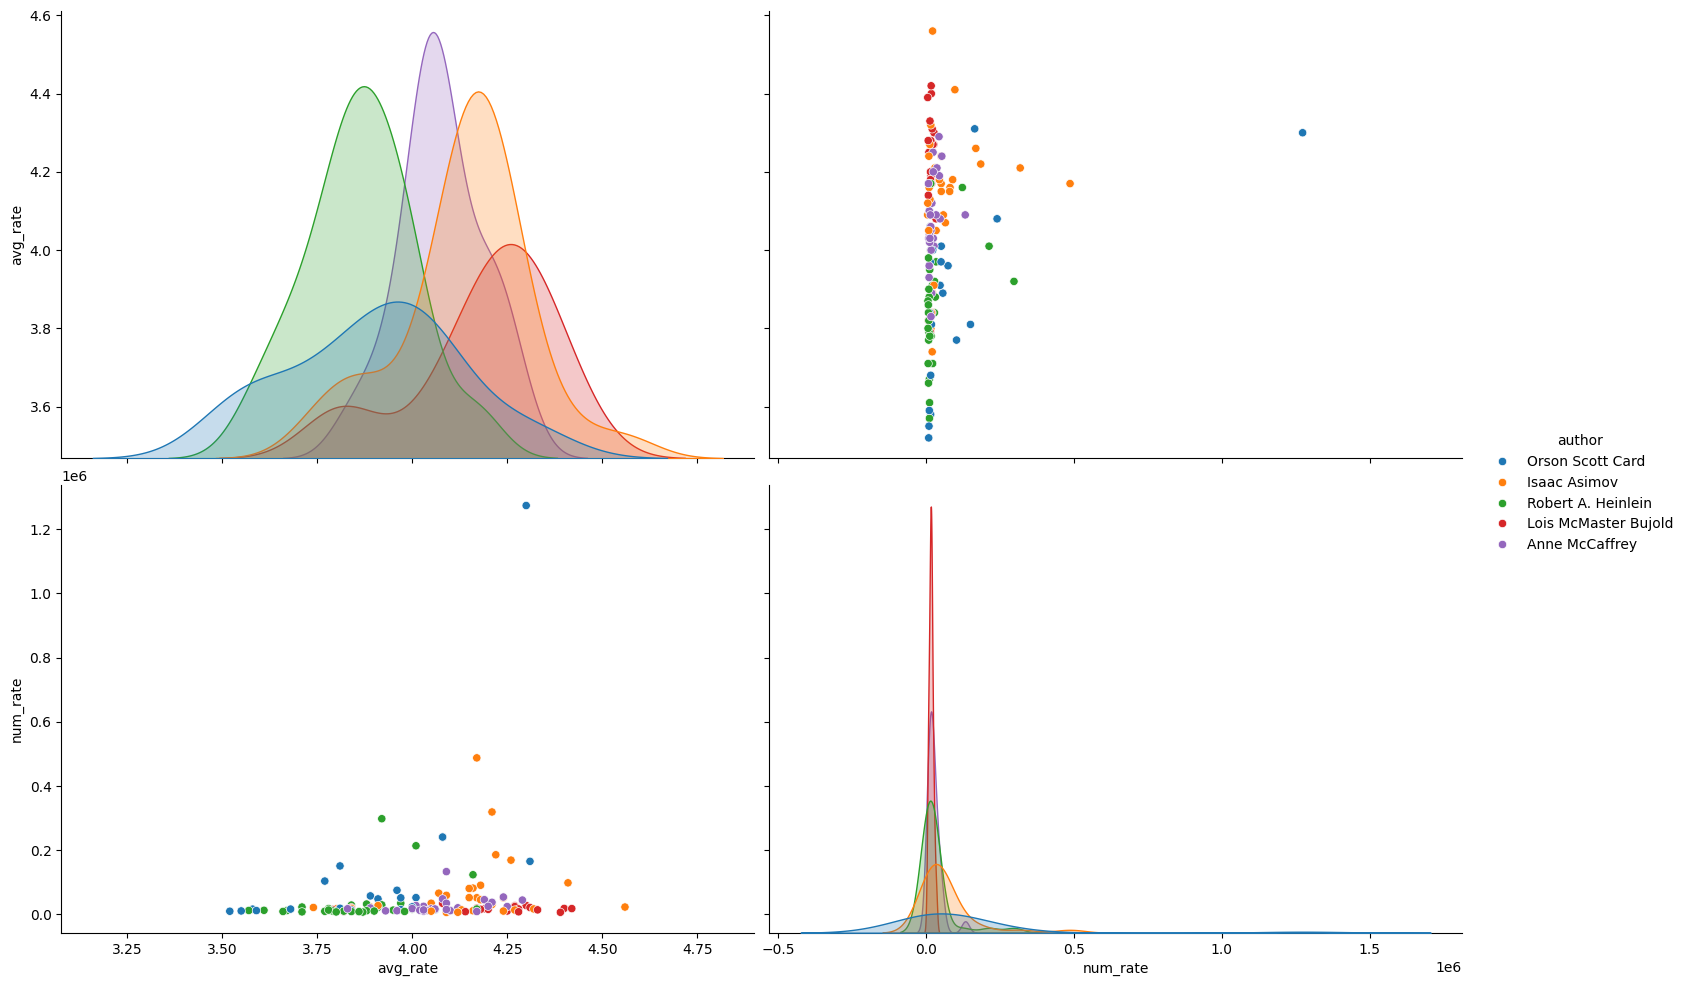

In [15]:
#a colorized pair plot to highlight some notable authors
df["author"].value_counts()

df_authors = df[df["author"].isin(["Robert A. Heinlein", "Isaac Asimov", "Anne McCaffrey", "Orson Scott Card", "Lois McMaster Bujold"])]
sns.pairplot(df_authors[["avg_rate", "num_rate", "author"]], height=5, aspect=1.5, diag_kind="kde", hue="author")
